In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("powerplant_data.csv")

In [3]:
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
X = data.drop(columns = ["PE"])
y = data["PE"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
import torch
import torch.nn as nn
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,  dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)


In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=32)


Building ANN

In [10]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model = nn.Sequential(
            #1st hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
    
            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            #Output
            nn.Linear(6,1)
    )
    def forward(self,x):
        return self.model(x)
        

In [11]:
import torch.optim as optim

model = ANN()

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [12]:
epochs = 100
train_loss = []
val_loss = []
best_loss_Value = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb,yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss = crietrion(output,yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss/len(train_loader)
    train_loss.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            output = model(xb)
            loss = crietrion(output,yb)
            running_val_loss += loss.item()

    epoch_test_loss = running_val_loss/len(test_loader)
    val_loss.append(epoch_test_loss)

    print(f"epoch{epoch+1}/{epochs} ==> train loss = {epoch_train_loss}, val loss = {epoch_test_loss}")

    if(best_loss_Value>epoch_test_loss):
        best_loss_Value = epoch_test_loss
        torch.save(model.state_dict(),"best_model.pt")

epoch1/100 ==> train loss = 205345.75983072916, val loss = 202296.22395833334
epoch2/100 ==> train loss = 192049.47740885417, val loss = 176155.57734375
epoch3/100 ==> train loss = 150389.09671223958, val loss = 121141.17708333333
epoch4/100 ==> train loss = 91353.78354492187, val loss = 65139.62454427083
epoch5/100 ==> train loss = 47186.727278645834, val loss = 34618.103515625
epoch6/100 ==> train loss = 27083.906494140625, val loss = 21931.137125651043
epoch7/100 ==> train loss = 18432.697115071616, val loss = 15939.129850260417
epoch8/100 ==> train loss = 13894.596915690105, val loss = 12092.48984375
epoch9/100 ==> train loss = 10449.510447184244, val loss = 8910.857674153645
epoch10/100 ==> train loss = 7552.689554850261, val loss = 6278.819742838542
epoch11/100 ==> train loss = 5231.54880472819, val loss = 4287.243538411459
epoch12/100 ==> train loss = 3507.1465520222982, val loss = 2860.82099609375
epoch13/100 ==> train loss = 2298.2204785664876, val loss = 1903.411659749349
epo

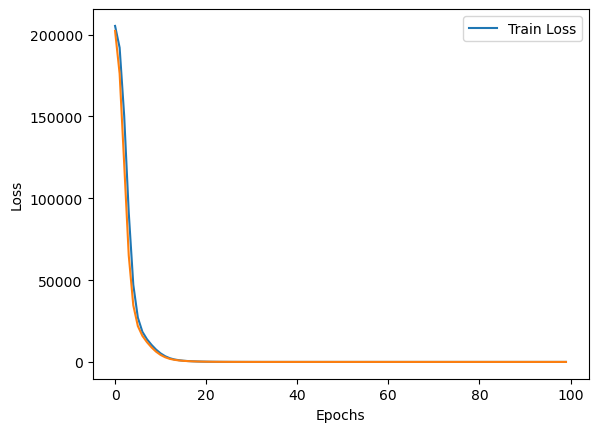

In [13]:
import matplotlib.pyplot as plt

data_df = pd.DataFrame({
    "train_loss": train_loss,
    "Val_loss" : val_loss}
)
plt.plot(data_df["train_loss"],label = "Train Loss")
plt.plot(data_df["Val_loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

In [14]:
#load the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [15]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.182737350463867
Testing MSE: 19.56793212890625


In [16]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9316151243453986


In [19]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.620911,433.27
1,437.260986,438.16
2,461.166748,458.42
3,475.856750,480.82
4,435.829803,441.41
...,...,...
1909,451.266968,456.70
1910,432.032532,438.04
1911,467.429993,467.80
1912,431.523376,437.14
